[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1bThMQQzQltc9HNytv6qK_FvkIstTJNEd)

## Data

The training set contains randomly selected 66.66% of the data from the original dataset. This will have all of the columns including whether or not the customer churned. The other 33.33% will be in the test dataset without any information about the customer churn.

Train - [https://www.dropbox.com/s/k8gtyoj4wnyj7nt/churn-train.csv?raw=1](https://www.dropbox.com/s/k8gtyoj4wnyj7nt/churn-train.csv?raw=1)

Test - [https://www.dropbox.com/s/4bdlqr70zjejq0m/churn-test.csv?raw=1](https://www.dropbox.com/s/4bdlqr70zjejq0m/churn-test.csv?raw=1)

In [0]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib as mpl
mpl.rcParams['figure.dpi']= 100

In [0]:
train_url = 'https://www.dropbox.com/s/k8gtyoj4wnyj7nt/churn-train.csv?raw=1'
test_url = 'https://www.dropbox.com/s/4bdlqr70zjejq0m/churn-test.csv?raw=1'

In [3]:
df = pd.read_csv(train_url)
df.head()

,id,state,account_length,area_code,phone,international_plan,vmail_plan,vmail_message,day_mins,day_calls,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,intl_mins,intl_calls,intl_charge,custserv_calls,churn
0,3200,CT,100,510,416-1536,yes,no,0,107.2,98,...,122,7.38,156.2,117,7.03,9.7,4,2.62,1,0
1,2129,CT,146,408,380-3329,no,yes,23,149.6,96,...,124,20.38,293.5,135,13.21,7.4,4,2,2,0
2,598,AZ,84,415,341-2360,no,no,0,159.0,80,...,128,14.27,167.6,101,7.54,12.3,5,3.32,1,0
3,2507,VT,43,408,331-8713,no,no,0,135.8,125,...,88,13.87,229.8,106,10.34,12.6,?,3.4,0,0
4,1248,PA,101,415,368-2074,?,no,0,193.7,108,...,?,15.86,223.0,100,?,11.6,8,3.13,0,0


## Data Understanding

In [4]:
print(len(df.columns))
df.columns

22


Index(['id', 'state', 'account_length', 'area_code', 'phone',
       'international_plan', 'vmail_plan', 'vmail_message', 'day_mins',
       'day_calls', 'day_charge', 'eve_mins', 'eve_calls', 'eve_charge',
       'night_mins', 'night_calls', 'night_charge', 'intl_mins', 'intl_calls',
       'intl_charge', 'custserv_calls', 'churn'],
      dtype='object')

In [5]:
pd.options.display.max_columns = None
df.head()

,id,state,account_length,area_code,phone,international_plan,vmail_plan,vmail_message,day_mins,day_calls,day_charge,eve_mins,eve_calls,eve_charge,night_mins,night_calls,night_charge,intl_mins,intl_calls,intl_charge,custserv_calls,churn
0,3200,CT,100,510,416-1536,yes,no,0,107.2,98,18.22,86.8,122,7.38,156.2,117,7.03,9.7,4,2.62,1,0
1,2129,CT,146,408,380-3329,no,yes,23,149.6,96,25.43,239.8,124,20.38,293.5,135,13.21,7.4,4,2,2,0
2,598,AZ,84,415,341-2360,no,no,0,159.0,80,27.03,167.9,128,14.27,167.6,101,7.54,12.3,5,3.32,1,0
3,2507,VT,43,408,331-8713,no,no,0,135.8,125,23.09,163.2,88,13.87,229.8,106,10.34,12.6,?,3.4,0,0
4,1248,PA,101,415,368-2074,?,no,0,193.7,108,32.93,186.6,?,15.86,223.0,100,?,11.6,8,3.13,0,0


In [6]:
df.shape

(2222, 22)

In [0]:
def check_unique_values(data, feature):
  unique = data[feature].unique()
  print("Total = %d | Type = %s" % (len(unique), data[feature].dtype))
  #print("Type =", data[feature].dtype)
  print(unique)

In [8]:
for each in df.columns:
  print("\n---%s---------------------------------------------------------" % each)
  check_unique_values(df, each)


---id---------------------------------------------------------
Total = 2222 | Type = int64
[3200 2129  598 ... 1414 1691 1867]

---state---------------------------------------------------------
Total = 51 | Type = object
['CT' 'AZ' 'VT' 'PA' 'OK' 'MD' 'OH' 'AL' 'AR' 'GA' 'DE' 'NV' 'VA' 'NM'
 'WV' 'ID' 'NH' 'NY' 'DC' 'ME' 'MI' 'KS' 'AK' 'TX' 'IN' 'SD' 'MO' 'NC'
 'UT' 'IL' 'CA' 'TN' 'OR' 'KY' 'HI' 'WA' 'MS' 'SC' 'ND' 'MT' 'CO' 'WY'
 'WI' 'MN' 'RI' 'NE' 'NJ' 'FL' 'LA' 'MA' 'IA']

---account_length---------------------------------------------------------
Total = 207 | Type = int64
[100 146  84  43 101 116  71  68  92  33  98  51  99  87 166 144 119 158
 180 193 128 121  78 126 153  77  50 209 164  89  61  86  79 160  21 104
 125 157  81  55  13  75 108  97 136 113 132  53 118 114  91 130  80 137
 147 150 141 131 148  94 155 177  29 109 111  93 115 112 124  35  66 172
 120 151 139  64  54  74  46  90  56  28  30 134 103  34 225  59 129  83
  85   9 107  52 163  45  19 135 122   3 142 117  

### Let's start with a Correlation Matrix for some inital intuition

**presence of '?' won't let us plot the required Heatmap/CorrelationMatrix – let's quickly get rid of it in a temporary fashion**

In [9]:
from sklearn.preprocessing import LabelEncoder

temp_data = df.copy()
for feature in ['state', 'phone', 'international_plan', 'vmail_plan']:
  temp_data[feature] = LabelEncoder().fit_transform(temp_data[feature])

temp_data = temp_data.apply(pd.to_numeric, errors='coerce')
temp_data.fillna(method='ffill', inplace=True)
temp_data.isnull().sum()

id                    0
state                 0
account_length        0
area_code             0
phone                 0
international_plan    0
vmail_plan            0
vmail_message         0
day_mins              0
day_calls             0
day_charge            0
eve_mins              0
eve_calls             0
eve_charge            0
night_mins            0
night_calls           0
night_charge          0
intl_mins             0
intl_calls            0
intl_charge           0
custserv_calls        0
churn                 0
dtype: int64

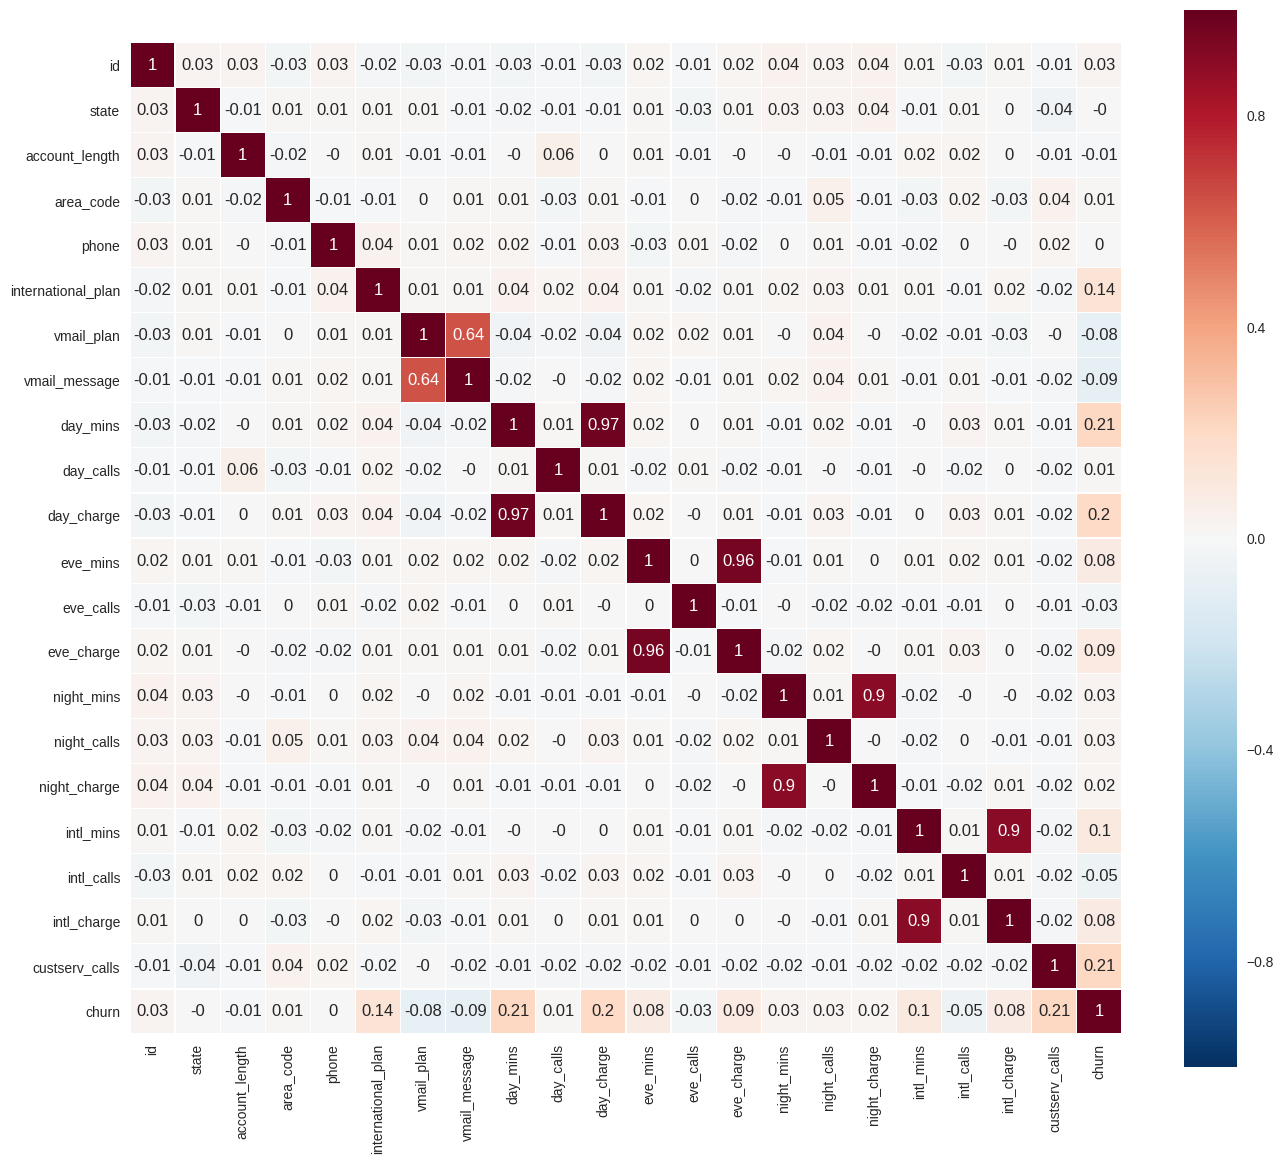

In [10]:
plt.figure(figsize=(16, 14))
sns.heatmap(np.round(temp_data.astype(float).corr(), 2), 
            linewidths=0.1, 
            square=True, 
            linecolor='white', 
            annot=True);

**Observation:** 

These features **standout** from an importance point of view (w.r.t. to their *potential* predictive powers):

1.   custserv_calls
2.   day_charge
3.   day_mins
4.   international_plan

***

These features seem to have neglibile correlation and potentially can be **discarded** for a quick baseline model:

1.   state
2.   area_code
3.   phone



## Data Preparation

Let's just drop `state`, `area_code` and `phone` for now – we can come back to them later on

In [0]:
train_dataset = df.drop(['state', 'area_code', 'phone'], axis=1)

Check where all `"?"`comes

In [12]:
print(train_dataset.dtypes)

id                      int64
account_length          int64
international_plan     object
vmail_plan             object
vmail_message           int64
day_mins              float64
day_calls               int64
day_charge             object
eve_mins               object
eve_calls              object
eve_charge            float64
night_mins            float64
night_calls             int64
night_charge           object
intl_mins             float64
intl_calls             object
intl_charge            object
custserv_calls          int64
churn                   int64
dtype: object


In [13]:
for each in train_dataset.columns:
  if '?' in train_dataset[each].unique():
    print(each)

international_plan
vmail_plan
day_charge
eve_mins
eve_calls
night_charge
intl_calls
intl_charge


/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:2: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  


In [14]:
train_dataset['international_plan'].unique()

array(['yes', 'no', '?'], dtype=object)

cleanup `international_plan`

In [0]:
def most_common_value(df, feature):
  return df[feature].value_counts().index[0]

In [0]:
def replace_most_common(df, val, feature):
  if val == '?':
    return most_common_value(df, feature)
  else:
    return val

In [17]:
feature = 'international_plan'
train_dataset[feature] = train_dataset[feature].apply(lambda val: replace_most_common(train_dataset, val, feature))
train_dataset[feature].unique()

array(['yes', 'no'], dtype=object)

same is the case with `vmail_plan` – fix that

In [18]:
train_dataset['vmail_plan'].unique()

array(['no', 'yes', '?'], dtype=object)

In [19]:
feature = 'vmail_plan'
train_dataset[feature] = train_dataset[feature].apply(lambda val: replace_most_common(train_dataset, val, feature))
train_dataset[feature].unique()

array(['no', 'yes'], dtype=object)

**1 clear observation is that some of the numeric features are represented as strings – let's fix those**

(not suprisingly these features are the ones which "?" inside them)

In [20]:
for each in ['day_charge', 'eve_mins', 'eve_calls', 'night_charge', 'intl_calls', 'intl_charge']:
  train_dataset[each] = train_dataset[each].apply(pd.to_numeric, errors='coerce')
  
train_dataset.isnull().sum()  

id                      0
account_length          0
international_plan      0
vmail_plan              0
vmail_message           0
day_mins                0
day_calls               0
day_charge             74
eve_mins               60
eve_calls             348
eve_charge              0
night_mins              0
night_calls             0
night_charge          200
intl_mins               0
intl_calls            455
intl_charge           229
custserv_calls          0
churn                   0
dtype: int64

**Let's study their distributions to decice how to cleanup the NaN values**

/usr/local/lib/python3.6/dist-packages/statsmodels/nonparametric/kde.py:454: RuntimeWarning: invalid value encountered in greater
  X = X[np.logical_and(X>clip[0], X<clip[1])] # won't work for two columns.
/usr/local/lib/python3.6/dist-packages/statsmodels/nonparametric/kde.py:454: RuntimeWarning: invalid value encountered in less
  X = X[np.logical_and(X>clip[0], X<clip[1])] # won't work for two columns.
/usr/local/lib/python3.6/dist-packages/statsmodels/nonparametric/kde.py:494: RuntimeWarning: invalid value encountered in true_divide
  binned = fast_linbin(X,a,b,gridsize)/(delta*nobs)
/usr/local/lib/python3.6/dist-packages/statsmodels/nonparametric/kdetools.py:34: RuntimeWarning: invalid value encountered in double_scalars
  FAC1 = 2*(np.pi*bw/RANGE)**2


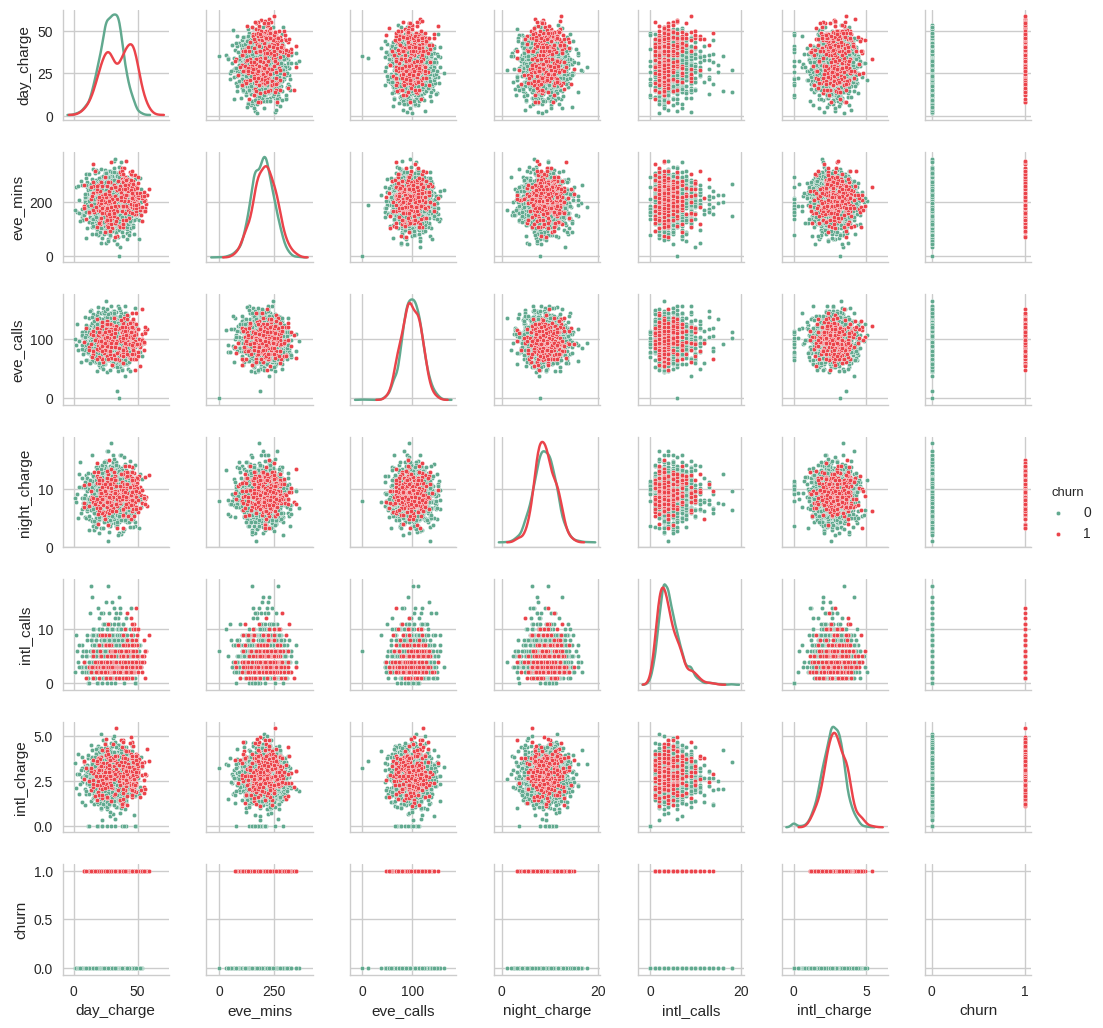

In [21]:
missing_ones = pd.DataFrame(train_dataset, columns=['day_charge', 'eve_mins', 'eve_calls', 'night_charge', 'intl_calls', 'intl_charge', 'churn'])

sns.set(style='whitegrid', color_codes=True)
sns.pairplot(missing_ones, 
             kind='scatter', 
             diag_kind='kde',
             hue='churn',
             size=1.5, 
             plot_kws={'s': 10},
             palette={0:'#61A98F', 1:'#EB434A'});

**Observation:**

1.   Apart from `intl_calls`, others seem to be normally distributed – so we can use median for `intl_calls`, and mean for the rest
2.   Another interesting observation is the `day_charge` distribution – there is a clear indication that the `day_charge` might be an influential factor in deciding churn



In [0]:
replace_with_mean = ['day_charge', 'eve_mins', 'eve_calls', 'night_charge', 'intl_charge']
replace_with_median = ['intl_calls']

In [0]:
from sklearn.preprocessing import Imputer

imputer = Imputer(missing_values=np.nan, strategy='mean', axis=0)
for feature in replace_with_mean:
  train_dataset[[feature]] = imputer.fit_transform(train_dataset[[feature]])

In [0]:
imputer = Imputer(missing_values=np.nan, strategy='median', axis=0)
for feature in replace_with_median:
  train_dataset[[feature]] = imputer.fit_transform(train_dataset[[feature]])

In [25]:
train_dataset.isnull().sum()

id                    0
account_length        0
international_plan    0
vmail_plan            0
vmail_message         0
day_mins              0
day_calls             0
day_charge            0
eve_mins              0
eve_calls             0
eve_charge            0
night_mins            0
night_calls           0
night_charge          0
intl_mins             0
intl_calls            0
intl_charge           0
custserv_calls        0
churn                 0
dtype: int64

In [26]:
train_dataset.head()

,id,account_length,international_plan,vmail_plan,vmail_message,day_mins,day_calls,day_charge,eve_mins,eve_calls,eve_charge,night_mins,night_calls,night_charge,intl_mins,intl_calls,intl_charge,custserv_calls,churn
0,3200,100,yes,no,0,107.2,98,18.22,86.8,122.000000,7.38,156.2,117,7.030000,9.7,4.0,2.62,1,0
1,2129,146,no,yes,23,149.6,96,25.43,239.8,124.000000,20.38,293.5,135,13.210000,7.4,4.0,2.00,2,0
2,598,84,no,no,0,159.0,80,27.03,167.9,128.000000,14.27,167.6,101,7.540000,12.3,5.0,3.32,1,0
3,2507,43,no,no,0,135.8,125,23.09,163.2,88.000000,13.87,229.8,106,10.340000,12.6,4.0,3.40,0,0
4,1248,101,no,no,0,193.7,108,32.93,186.6,99.797225,15.86,223.0,100,8.982913,11.6,8.0,3.13,0,0


**Last step is to convert binomials and categoricals to encoded labels**

In [27]:
from sklearn.preprocessing import LabelEncoder

for each in ['international_plan', 'vmail_plan']:
  train_dataset[each] = LabelEncoder().fit_transform(train_dataset[each])

train_dataset.head()

,id,account_length,international_plan,vmail_plan,vmail_message,day_mins,day_calls,day_charge,eve_mins,eve_calls,eve_charge,night_mins,night_calls,night_charge,intl_mins,intl_calls,intl_charge,custserv_calls,churn
0,3200,100,1,0,0,107.2,98,18.22,86.8,122.000000,7.38,156.2,117,7.030000,9.7,4.0,2.62,1,0
1,2129,146,0,1,23,149.6,96,25.43,239.8,124.000000,20.38,293.5,135,13.210000,7.4,4.0,2.00,2,0
2,598,84,0,0,0,159.0,80,27.03,167.9,128.000000,14.27,167.6,101,7.540000,12.3,5.0,3.32,1,0
3,2507,43,0,0,0,135.8,125,23.09,163.2,88.000000,13.87,229.8,106,10.340000,12.6,4.0,3.40,0,0
4,1248,101,0,0,0,193.7,108,32.93,186.6,99.797225,15.86,223.0,100,8.982913,11.6,8.0,3.13,0,0


## Modeling

**Let's try for a quick baseline model**

In [0]:
Y_train = train_dataset['churn']
X_train = train_dataset.drop(['churn'], axis=1)

In [0]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

**Logistic Regression**

In [30]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
cross_val = KFold(n_splits=5, random_state=42)
scores = cross_val_score(model, X_train, Y_train, cv=cross_val, scoring='roc_auc')
print("Mean AUC Score - Logistic Regression: ", scores.mean())

Mean AUC Score - Logistic Regression:  0.798857612906082


**Support Vector Machine**

In [31]:
from sklearn.svm import SVC

model = SVC()
cross_val = KFold(n_splits=5, random_state=42)
scores = cross_val_score(model, X_train, Y_train, cv=cross_val, scoring='roc_auc')
print("Mean AUC Score - Support Vector Machine: ", scores.mean())

Mean AUC Score - Support Vector Machine:  0.5


**Decision Tree Classifier**

In [32]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
cross_val = KFold(n_splits=5, random_state=42)
scores = cross_val_score(model, X_train, Y_train, cv=cross_val, scoring='roc_auc')
print("Mean AUC Score - Decision Tree: ", scores.mean())

Mean AUC Score - Decision Tree:  0.8238122042289868


**Random Forest**

In [33]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
cross_val = KFold(n_splits=5, random_state=42) 
scores = cross_val_score(model, X_train, Y_train, cv=cross_val, scoring='roc_auc')
print("Mean AUC Score - Random Forest: ", scores.mean())

Mean AUC Score - Random Forest:  0.8875613631466261


**Naive Bayes Classifier**

In [34]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
cross_val = KFold(n_splits=5, random_state=42) 
scores = cross_val_score(model, X_train, Y_train, cv=cross_val, scoring='roc_auc')
print("Mean AUC Score - Naive Bayes: ", scores.mean())

Mean AUC Score - Naive Bayes:  0.8308304539526683


**K-Nearest Neighbors Classifier**

In [35]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier()
cross_val = KFold(n_splits=5, random_state=42) 
scores = cross_val_score(model, X_train, Y_train, cv=cross_val, scoring='roc_auc')
print("Mean AUC Score - K-Nearest Neighbors: ", scores.mean())

Mean AUC Score - K-Nearest Neighbors:  0.6006002042008084


**Observation:**

1.   KNeighborsClassifier looks weak – we ll discard that for now
2.   SVM looks suspicious – as it gives 0.5 accuracy each time – looks like something is wrong – take a look later
***



**Highest performing model's hyperparameters:**

**Random Forest**

1.   *n_estimators* : integer, optional (default=10)
2.   *max_features* : int, float, string or None, optional (default=”auto”)
3.   *bootstrap* : boolean, optional (default=True)
4.   *oob_score* : bool (default=False)
5.   *verbose* : int, optional (default=0)
6.   *min_samples_split* : int, float, optional (default=2)


**Second highest performing model's hyperparameters:**

**Decision Tree**

looks like doesn't have any hyperparameters to tune – but other factors can influence its performance : [Better Naive Bayes](https://machinelearningmastery.com/better-naive-bayes/)




## Evaluation

In [40]:
df_test = pd.read_csv(test_url)
df_test.head()

,id,state,account_length,area_code,phone,international_plan,vmail_plan,vmail_message,day_mins,day_calls,day_charge,eve_mins,eve_calls,eve_charge,night_mins,night_calls,night_charge,intl_mins,intl_calls,intl_charge,custserv_calls,churn
0,221,TN,127,408,336-1090,no,yes,22,166.0,114,28.22,174.5,103,14.83,244.9,68,11.02,10.2,6,2.75,1,9999
1,1313,CT,100,415,389-2114,no,no,0,235.8,130,40.09,176,?,14.96,63.6,122,2.86,7.3,1,1.97,2,9999
2,1635,AZ,66,510,337-8618,no,no,0,154.0,133,26.18,198.9,121,16.91,151.9,100,6.84,9.5,3,2.57,4,9999
3,289,OK,89,510,352-6976,no,no,0,303.9,95,51.66,260.9,114,22.18,312.1,89,14.04,5.3,?,1.43,1,9999
4,2416,IA,113,510,335-8427,?,no,0,156.0,141,26.52,256.8,72,21.83,175.3,123,7.89,11.9,5,3.21,2,9999


### Follow the exact same steps for test_dataset as we did for train_dataset

construct a single function `cleanup_dataset()` which will do all the above data prep steps for any given dataset

In [0]:
from sklearn.preprocessing import Imputer
from sklearn.preprocessing import LabelEncoder

def cleanup_dataset(dfset):
  dataset = dfset.copy()
  print(dataset.shape)
  dataset = dataset.drop(['state', 'area_code', 'phone'], axis=1)
  print(dataset.shape)
  
  features = ['international_plan', 'vmail_plan']
  for each in features:
    dataset[each] = dataset[each].apply(lambda val: replace_most_common(dataset, val, each))
    print(dataset[each].unique())
    
  for each in ['day_charge', 'eve_mins', 'eve_calls', 'night_charge', 'intl_calls', 'intl_charge']:
    dataset[each] = dataset[each].apply(pd.to_numeric, errors='coerce')

  print(dataset.isnull().sum())  

  replace_with_mean = ['day_charge', 'eve_mins', 'eve_calls', 'night_charge', 'intl_charge']
  replace_with_median = ['intl_calls']
  
  imputer = Imputer(missing_values=np.nan, strategy='mean', axis=0)
  for each in replace_with_mean:
    print(each)
    print(dataset[each].isnull().sum())
    dataset[[each]] = imputer.fit_transform(dataset[[each]])
    print(dataset[each].isnull().sum())

  imputer = Imputer(missing_values=np.nan, strategy='median', axis=0)
  for each in replace_with_median:
    print(each)
    print(dataset[each].isnull().sum())
    dataset[[each]] = imputer.fit_transform(dataset[[each]])
    print(dataset[each].isnull().sum())
  
  print(dataset.isnull().sum())  
  
  for each in ['international_plan', 'vmail_plan']:
    dataset[each] = LabelEncoder().fit_transform(dataset[each])  
  
  return dataset

In [42]:
test_dataset = cleanup_dataset(df_test)
test_dataset.head()

(1111, 22)
(1111, 19)
['no' 'yes']
['yes' 'no']
id                      0
account_length          0
international_plan      0
vmail_plan              0
vmail_message           0
day_mins                0
day_calls               0
day_charge             38
eve_mins               28
eve_calls             172
eve_charge              0
night_mins              0
night_calls             0
night_charge          110
intl_mins               0
intl_calls            207
intl_charge           123
custserv_calls          0
churn                   0
dtype: int64
day_charge
38
0
eve_mins
28
0
eve_calls
172
0
night_charge
110
0
intl_charge
123
0
intl_calls
207
0
id                    0
account_length        0
international_plan    0
vmail_plan            0
vmail_message         0
day_mins              0
day_calls             0
day_charge            0
eve_mins              0
eve_calls             0
eve_charge            0
night_mins            0
night_calls           0
night_charge          0
intl_mins

,id,account_length,international_plan,vmail_plan,vmail_message,day_mins,day_calls,day_charge,eve_mins,eve_calls,eve_charge,night_mins,night_calls,night_charge,intl_mins,intl_calls,intl_charge,custserv_calls,churn
0,221,127,0,1,22,166.0,114,28.22,174.5,103.000000,14.83,244.9,68,11.02,10.2,6.0,2.75,1,9999
1,1313,100,0,0,0,235.8,130,40.09,176.0,100.865815,14.96,63.6,122,2.86,7.3,1.0,1.97,2,9999
2,1635,66,0,0,0,154.0,133,26.18,198.9,121.000000,16.91,151.9,100,6.84,9.5,3.0,2.57,4,9999
3,289,89,0,0,0,303.9,95,51.66,260.9,114.000000,22.18,312.1,89,14.04,5.3,4.0,1.43,1,9999
4,2416,113,0,0,0,156.0,141,26.52,256.8,72.000000,21.83,175.3,123,7.89,11.9,5.0,3.21,2,9999


In [0]:
X_test = test_dataset.drop(['churn'], axis=1)

In [44]:
X_test.head()

,id,account_length,international_plan,vmail_plan,vmail_message,day_mins,day_calls,day_charge,eve_mins,eve_calls,eve_charge,night_mins,night_calls,night_charge,intl_mins,intl_calls,intl_charge,custserv_calls
0,221,127,0,1,22,166.0,114,28.22,174.5,103.000000,14.83,244.9,68,11.02,10.2,6.0,2.75,1
1,1313,100,0,0,0,235.8,130,40.09,176.0,100.865815,14.96,63.6,122,2.86,7.3,1.0,1.97,2
2,1635,66,0,0,0,154.0,133,26.18,198.9,121.000000,16.91,151.9,100,6.84,9.5,3.0,2.57,4
3,289,89,0,0,0,303.9,95,51.66,260.9,114.000000,22.18,312.1,89,14.04,5.3,4.0,1.43,1
4,2416,113,0,0,0,156.0,141,26.52,256.8,72.000000,21.83,175.3,123,7.89,11.9,5.0,3.21,2


**Generate submission with RandomForest**

In [0]:
from google.colab import files

def generate_submission(model, x_train, y_train, x_test):
  print("Generating final submission...")
  print("Training model on the entire set...")
  model.fit(x_train, y_train)
  y_predict = model.predict(x_test)
  
  submission = pd.DataFrame(df_test, columns=['id'])
  submission['churn'] = y_predict  

  print("\nsubmission.head(10):")
  print(submission.head(10))
  
  submission.to_csv('kaggle_submission.csv', index = False)
  files.download('kaggle_submission.csv')

In [46]:
model = RandomForestClassifier()
generate_submission(model, X_train, Y_train, X_test)

Generating final submission...
Training model on the entire set...

submission.head(10):
     id  churn
0   221      0
1  1313      0
2  1635      1
3   289      1
4  2416      0
5  3112      1
6   601      1
7   326      0
8  2783      0
9   454      1


## Hyperparam Tuning

In [0]:
from sklearn.model_selection import GridSearchCV

def run_grid_search(model, hyperparameters, x, y):
  grid_search = GridSearchCV(model, hyperparameters, cv=5, verbose=1, scoring='roc_auc')
  best_model = grid_search.fit(x, y)
  return best_model

### RandomForest

In [48]:
n_estimators = [10, 50, 100, 150, 200, 250, 300, 400, 500, 600, 700]
max_features = ['auto', 'log2', None, 2, 3, 5]
min_samples_split = [2, 5, 10, 12, 15]
min_samples_leaf = [1, 2, 3, 4, 5]

hyperparameters = dict(n_estimators=n_estimators,
                       max_features=max_features,                       
                       min_samples_split=min_samples_split,
                       min_samples_leaf=min_samples_leaf)
hyperparameters

{'max_features': ['auto', 'log2', None, 2, 3, 5],
 'min_samples_leaf': [1, 2, 3, 4, 5],
 'min_samples_split': [2, 5, 10, 12, 15],
 'n_estimators': [10, 50, 100, 150, 200, 250, 300, 400, 500, 600, 700]}

In [0]:
# model = RandomForestClassifier()
# best_model = run_grid_search(model, hyperparameters, X_train_normalized, Y_train)

# for each in hyperparameters:
#   print(each)
#   print(best_model.best_estimator_.get_params()[each])

**Best hyperparameters found for RandomForest**

In [49]:
model = RandomForestClassifier(n_estimators=700, max_features=5, min_samples_split=12, min_samples_leaf=1)
cross_val = KFold(n_splits=5, random_state=42) 
scores = cross_val_score(model, X_train, Y_train, cv=cross_val, scoring='roc_auc')
print("Mean AUC Score - Random Forest: ", scores.mean())

Mean AUC Score - Random Forest:  0.9002387236522027


### Try Normalization

In [0]:
import sklearn.preprocessing as preprocessing

def normalize(dataset):
  dataset_normalized = pd.DataFrame(preprocessing.StandardScaler().fit_transform(dataset))
  return dataset_normalized

In [51]:
X_train_normalized = normalize(X_train)
X_train_normalized.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,1.598541,-0.006865,3.409545,-0.556904,-0.579395,-1.316713,-0.101346,-1.343116,-2.289923,1.228993,-2.256715,-0.868827,0.865660,-0.900905,-0.190658,-0.181668,-0.202049,-0.446258
1,0.486093,1.137743,-0.293294,1.795643,1.106472,-0.538214,-0.202806,-0.549727,0.799695,1.339700,0.788694,1.864227,1.790098,1.950011,-1.015700,-0.181668,-1.067613,0.329023
2,-1.104158,-0.404989,-0.293294,-0.556904,-0.579395,-0.365622,-1.014487,-0.373663,-0.652224,1.561112,-0.642648,-0.641902,0.043938,-0.665635,0.741999,0.271380,0.775202,-0.446258
3,0.878721,-1.425183,-0.293294,-0.556904,-0.579395,-0.791593,1.268365,-0.807221,-0.747133,-0.653013,-0.736353,0.596233,0.300726,0.626042,0.849613,-0.181668,0.886888,-1.221539
4,-0.429002,0.018018,-0.293294,-0.556904,-0.579395,0.271498,0.405955,0.275574,-0.274604,0.000000,-0.270171,0.460875,-0.007419,0.000000,0.490899,1.630522,0.509948,-1.221539


In [52]:
model = LogisticRegression()
cross_val = KFold(n_splits=5, random_state=42)
scores = cross_val_score(model, X_train_normalized, Y_train, cv=cross_val, scoring='roc_auc')
print("Mean AUC Score - Logistic Regression: ", scores.mean())

Mean AUC Score - Logistic Regression:  0.8092600572577465


In [53]:
model = SVC()
cross_val = KFold(n_splits=5, random_state=42)
scores = cross_val_score(model, X_train_normalized, Y_train, cv=cross_val, scoring='roc_auc')
print("Mean AUC Score - Support Vector Machine: ", scores.mean())

Mean AUC Score - Support Vector Machine:  0.8879432969239633


In [54]:
model = DecisionTreeClassifier()
cross_val = KFold(n_splits=5, random_state=42)
scores = cross_val_score(model, X_train_normalized, Y_train, cv=cross_val, scoring='roc_auc')
print("Mean AUC Score - Decision Tree: ", scores.mean())

Mean AUC Score - Decision Tree:  0.821575734472432


In [55]:
model = RandomForestClassifier()
cross_val = KFold(n_splits=5, random_state=42) 
scores = cross_val_score(model, X_train_normalized, Y_train, cv=cross_val, scoring='roc_auc')
print("Mean AUC Score - Random Forest: ", scores.mean())

Mean AUC Score - Random Forest:  0.8791578280738245


In [56]:
model = GaussianNB()
cross_val = KFold(n_splits=5, random_state=42) 
scores = cross_val_score(model, X_train_normalized, Y_train, cv=cross_val, scoring='roc_auc')
print("Mean AUC Score - Naive Bayes: ", scores.mean())

Mean AUC Score - Naive Bayes:  0.8305531321213415


In [57]:
model = KNeighborsClassifier()
cross_val = KFold(n_splits=5, random_state=42) 
scores = cross_val_score(model, X_train_normalized, Y_train, cv=cross_val, scoring='roc_auc')
print("Mean AUC Score - K-Nearest Neighbors: ", scores.mean())

Mean AUC Score - K-Nearest Neighbors:  0.8119584773383665


**Observation:**

1.   SVM starts to behave normally with normalization
2.   KNeighbors' accuracy also rises by a whooping 20% and reaches >80%
3.   Most of the others also improve (apart from RandomForest – which doesn't seem to be affected by normalization)

**We ll keep the normalization step in our pipeline as it feels important for some algorithms, and doesn't harm the others.**



### Try different features

Let's plot Correlation Heatmap again

In [0]:
temp_data = X_train.join(Y_train)

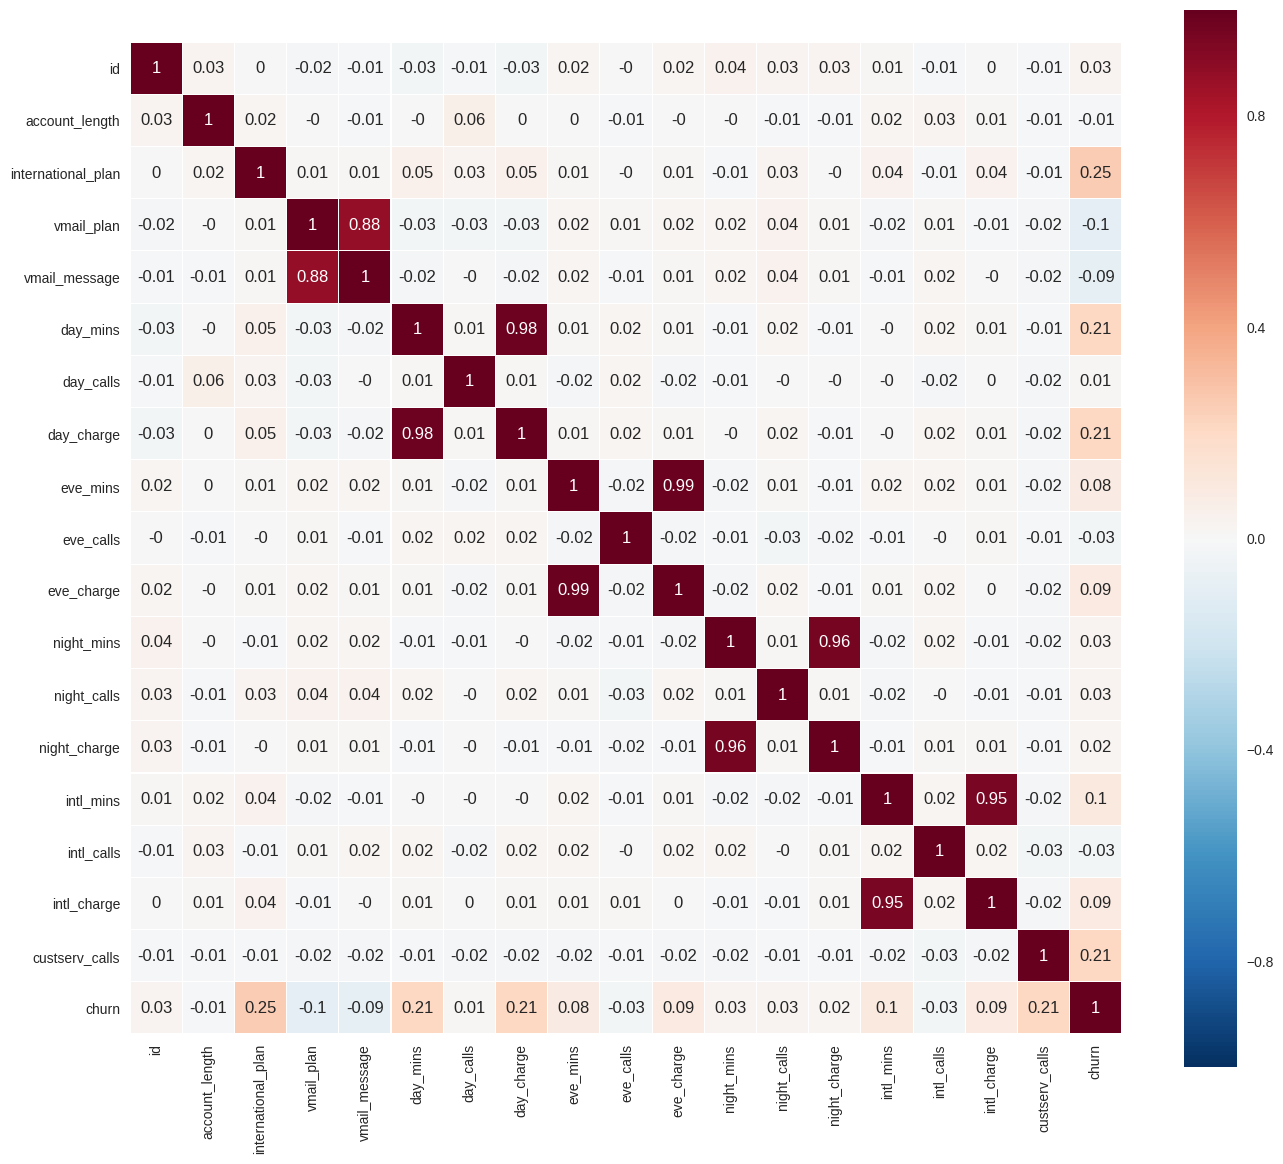

In [59]:
plt.figure(figsize=(16, 14))
sns.heatmap(np.round(temp_data.astype(float).corr(), 2), 
            linewidths=0.1, 
            square=True, 
            linecolor='white', 
            annot=True);

**Observation:** `international_plan` seems to be a big indicator of churn – let's try to experiment with some features around it

**Let's create a function update_feature_set() to experiment with feature engineering**

In [0]:
def update_feature_set(dataset):
  updated_dataset = dataset.copy()
  updated_dataset['pain_of_intl_calling'] = updated_dataset['international_plan'] * updated_dataset['intl_mins']
  return updated_dataset

In [61]:
X_train = update_feature_set(X_train)
X_train.head()

,id,account_length,international_plan,vmail_plan,vmail_message,day_mins,day_calls,day_charge,eve_mins,eve_calls,eve_charge,night_mins,night_calls,night_charge,intl_mins,intl_calls,intl_charge,custserv_calls,pain_of_intl_calling
0,3200,100,1,0,0,107.2,98,18.22,86.8,122.000000,7.38,156.2,117,7.030000,9.7,4.0,2.62,1,9.7
1,2129,146,0,1,23,149.6,96,25.43,239.8,124.000000,20.38,293.5,135,13.210000,7.4,4.0,2.00,2,0.0
2,598,84,0,0,0,159.0,80,27.03,167.9,128.000000,14.27,167.6,101,7.540000,12.3,5.0,3.32,1,0.0
3,2507,43,0,0,0,135.8,125,23.09,163.2,88.000000,13.87,229.8,106,10.340000,12.6,4.0,3.40,0,0.0
4,1248,101,0,0,0,193.7,108,32.93,186.6,99.797225,15.86,223.0,100,8.982913,11.6,8.0,3.13,0,0.0


In [62]:
model = RandomForestClassifier(n_estimators=700, max_features=5, min_samples_leaf=3, min_samples_split=12)
cross_val = KFold(n_splits=5, random_state=42) 
scores = cross_val_score(model, X_train, Y_train, cv=cross_val, scoring='roc_auc')
print("Mean AUC Score - Random Forest: ", scores.mean())

Mean AUC Score - Random Forest:  0.900694232815377


**Observation:** definite improvement

---

### Before putting more effort into 'Feature Engineering' – let's go back to the start and study the missing data again with more depth and make sure our data prep is solid before experimenting with features

In [63]:
pd.options.display.max_columns = None
df = pd.read_csv(train_url)
df.head()

,id,state,account_length,area_code,phone,international_plan,vmail_plan,vmail_message,day_mins,day_calls,day_charge,eve_mins,eve_calls,eve_charge,night_mins,night_calls,night_charge,intl_mins,intl_calls,intl_charge,custserv_calls,churn
0,3200,CT,100,510,416-1536,yes,no,0,107.2,98,18.22,86.8,122,7.38,156.2,117,7.03,9.7,4,2.62,1,0
1,2129,CT,146,408,380-3329,no,yes,23,149.6,96,25.43,239.8,124,20.38,293.5,135,13.21,7.4,4,2,2,0
2,598,AZ,84,415,341-2360,no,no,0,159.0,80,27.03,167.9,128,14.27,167.6,101,7.54,12.3,5,3.32,1,0
3,2507,VT,43,408,331-8713,no,no,0,135.8,125,23.09,163.2,88,13.87,229.8,106,10.34,12.6,?,3.4,0,0
4,1248,PA,101,415,368-2074,?,no,0,193.7,108,32.93,186.6,?,15.86,223.0,100,?,11.6,8,3.13,0,0


**2 columns which should have been dropped earlier, but were missed:**

1.   `id` : this is a unique identifier and will be different for each customer – chances of it having any predictive power is almost 0.
2.   `account_length` : looking from the CorrelationHeatmap, it looks like this feature also just adds noise and gives no preditive power.



In [64]:
dataset = df.copy()
print(dataset.shape)
dataset = dataset.drop(['state', 'area_code', 'phone', 'id', 'account_length'], axis=1)
print(dataset.shape)

(2222, 22)
(2222, 17)


***
**MISSING VALUES**
***

1 important to note is that **`xyz_mins` is NOT having any missing values** for any of `day`, `eve`, `night`,  `intl`

This means `xyz_charge`, which could be a strong factor in determining churn (CorrelationHeatmap agrees) – can be reliably filled in as the `xyz_rate_per_min` should be constant. ($charge = rate \times mins$)

There is **1 exception to the above** – Internation Calling – because of the existence of the option of `international_plan` – let's check that 1st and see what we can do about it

**International Calling**

Check `intl_charge_per_min`

In [65]:
rates = dataset[(dataset['international_plan']!='?') & (dataset['intl_charge']!='?')][['international_plan', 'intl_mins', 'intl_charge']]
rates['intl_charge'] = rates['intl_charge'].apply(pd.to_numeric, errors='coerce')
rates['charge_per_min'] = rates['intl_charge']/rates['intl_mins']
rates

,international_plan,intl_mins,intl_charge,charge_per_min
0,yes,9.7,2.62,0.270103
1,no,7.4,2.00,0.270270
2,no,12.3,3.32,0.269919
3,no,12.6,3.40,0.269841
5,no,7.5,2.03,0.270667
6,no,13.1,3.54,0.270229
7,no,15.5,4.19,0.270323
8,no,8.9,2.40,0.269663
9,yes,6.4,1.73,0.270312
10,no,12.0,3.24,0.270000


**Observation:**

1.   **International plan is useless**! it is not affecting the international rates at all – and not giving any preference to the customers having it – this means 2 things, one that we can just use $charge = rate \times mins$ for International Calling also, and two that this must be a big source of frustration for the customers leading to churn (CorrelationHeatmap highly agrees) – this means that an important feature could be constructed from this.
2.   the charge per min is constant ~ 0.27 => using that we can fill in intl_charge as intl_mins doesn't have any missing values



create functions for the above, so that we can use them for `day`, `eve` and `night` calling also

In [0]:
def check_charge_per_min(dataset, charge_feature, mins_feature):
  rates = dataset[(dataset[charge_feature]!='?')][[mins_feature, charge_feature]]
  rates[charge_feature] = rates[charge_feature].apply(pd.to_numeric, errors='coerce')
  rates['charge_per_min'] = rates[charge_feature]/rates[mins_feature]
  print(rates.head())

In [0]:
def update_missing_charge_as_per_calling_rate(dataset, charge_feature, mins_feature, calling_rate):
  print("update_charge_as_per_calling_rate – ", charge_feature)
  dataset[charge_feature] = dataset[charge_feature].apply(pd.to_numeric, errors='coerce')

  print("missing before -", dataset[charge_feature].isnull().sum())
  updated_charge = pd.Series()
  for i, row in dataset.iterrows():
    val = row[charge_feature]
    updated_val = calling_rate*row[mins_feature] if pd.isnull(val) else val
    updated_charge.set_value(i, updated_val)

  dataset[charge_feature] = updated_charge

  print("missing after -", dataset[charge_feature].isnull().sum())

Try for Internation Calling

In [68]:
check_charge_per_min(dataset, 'intl_charge', 'intl_mins')

   intl_mins  intl_charge  charge_per_min
0        9.7         2.62        0.270103
1        7.4         2.00        0.270270
2       12.3         3.32        0.269919
3       12.6         3.40        0.269841
4       11.6         3.13        0.269828


In [69]:
intl_rate = 0.27
update_missing_charge_as_per_calling_rate(dataset, 'intl_charge', 'intl_mins', intl_rate)

update_charge_as_per_calling_rate –  intl_charge
missing before - 229


/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:10: FutureWarning: set_value is deprecated and will be removed in a future release. Please use .at[] or .iat[] accessors instead
  # Remove the CWD from sys.path while we load stuff.


missing after - 0


As `international_plan` doesn't affect the final charges, it's impossible to derive it from other values – so we are forced to just use the `most_common_value`

In [70]:
feature = 'international_plan'
print("before -", dataset[feature].unique())
dataset[feature] = dataset[feature].apply(lambda val: replace_most_common(dataset, val, feature))
print("after -", dataset[feature].unique())

before - ['yes' 'no' '?']
after - ['yes' 'no']


number of calls can be anything – we have no way to make an educated guess on that – so just replace by median

In [71]:
from sklearn.preprocessing import Imputer

dataset['intl_calls'] = dataset['intl_calls'].apply(pd.to_numeric, errors='coerce')

print("missing before -", dataset['intl_calls'].isnull().sum())
imputer = Imputer(missing_values=np.nan, strategy='median', axis=0)
dataset[['intl_calls']] = imputer.fit_transform(dataset[['intl_calls']])
print("missing after -", dataset['intl_calls'].isnull().sum())

missing before - 455
missing after - 0


**Day Calls**

In [72]:
check_charge_per_min(dataset, 'day_charge', 'day_mins')

   day_mins  day_charge  charge_per_min
0     107.2       18.22        0.169963
1     149.6       25.43        0.169987
2     159.0       27.03        0.170000
3     135.8       23.09        0.170029
4     193.7       32.93        0.170005


In [73]:
day_rate = 0.17
update_missing_charge_as_per_calling_rate(dataset, 'day_charge', 'day_mins', day_rate)

update_charge_as_per_calling_rate –  day_charge
missing before - 74


/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:10: FutureWarning: set_value is deprecated and will be removed in a future release. Please use .at[] or .iat[] accessors instead
  # Remove the CWD from sys.path while we load stuff.


missing after - 0


**Eve calls**

Missing values are `eve_mins` and `eve_calls` – impossible to fill based on just `eve_charge`  – so just fill in with mean

In [74]:
replace_with_mean = ['eve_mins']
replace_with_mean_rounded = ['eve_calls'] # note: we don't want calls to be a float

imputer = Imputer(missing_values=np.nan, strategy='mean', axis=0)
for each in replace_with_mean:
  print(each)
  dataset[each] = dataset[each].apply(pd.to_numeric, errors='coerce')
  print("missing before -", dataset[each].isnull().sum())
  dataset[[each]] = imputer.fit_transform(dataset[[each]])    
  print("missing after -", dataset[each].isnull().sum())

for each in replace_with_mean_rounded:
  print(each)
  dataset[each] = dataset[each].apply(pd.to_numeric, errors='coerce')
  print("missing before -", dataset[each].isnull().sum())
  dataset[[each]] = imputer.fit_transform(dataset[[each]])
  dataset[each] = dataset[each].astype('int32')
  print("missing after -", dataset[each].isnull().sum())

eve_mins
missing before - 60
missing after - 0
eve_calls
missing before - 348
missing after - 0


In [75]:
check_charge_per_min(dataset, 'night_charge', 'night_mins')

   night_mins  night_charge  charge_per_min
0       156.2          7.03        0.045006
1       293.5         13.21        0.045009
2       167.6          7.54        0.044988
3       229.8         10.34        0.044996
7       215.6          9.70        0.044991


In [76]:
night_rate = 0.045
update_missing_charge_as_per_calling_rate(dataset, 'night_charge', 'night_mins', night_rate)

update_charge_as_per_calling_rate –  night_charge
missing before - 200


/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:10: FutureWarning: set_value is deprecated and will be removed in a future release. Please use .at[] or .iat[] accessors instead
  # Remove the CWD from sys.path while we load stuff.


missing after - 0


fix `vmail_plan`

In [77]:
feature = 'vmail_plan'
print("before -", dataset[feature].unique())
dataset[feature] = dataset[feature].apply(lambda val: replace_most_common(dataset, val, feature))
print("after -", dataset[feature].unique())

before - ['no' 'yes' '?']
after - ['no' 'yes']


In [78]:
print(dataset.isnull().sum())

international_plan    0
vmail_plan            0
vmail_message         0
day_mins              0
day_calls             0
day_charge            0
eve_mins              0
eve_calls             0
eve_charge            0
night_mins            0
night_calls           0
night_charge          0
intl_mins             0
intl_calls            0
intl_charge           0
custserv_calls        0
churn                 0
dtype: int64


### Let's update `cleanup_dataset()` as per the above

### And let's write down all the steps needed to experiment, in order  – so that we can tweak features and  re-run them

In [0]:
from sklearn.preprocessing import Imputer
from sklearn.preprocessing import LabelEncoder

def cleanup_dataset(dfset):
  dataset = dfset.copy()
  print(dataset.shape)
  print("dropping irrelevant columns...")
  dataset = dataset.drop(['state', 'area_code', 'phone', 'id', 'account_length'], axis=1)
  print(dataset.shape)
  
  check_charge_per_min(dataset, 'intl_charge', 'intl_mins')
  update_missing_charge_as_per_calling_rate(dataset, 'intl_charge', 'intl_mins', 0.27)  
  check_charge_per_min(dataset, 'day_charge', 'day_mins')
  update_missing_charge_as_per_calling_rate(dataset, 'day_charge', 'day_mins', 0.17)
  check_charge_per_min(dataset, 'night_charge', 'night_mins')
  update_missing_charge_as_per_calling_rate(dataset, 'night_charge', 'night_mins', 0.045)
  
  replace_with_mean = ['eve_mins']
  replace_with_mean_rounded = ['eve_calls']
  replace_with_median = ['intl_calls']
  
  imputer = Imputer(missing_values=np.nan, strategy='mean', axis=0)
  for each in replace_with_mean:
    print(each)
    dataset[each] = dataset[each].apply(pd.to_numeric, errors='coerce')
    print("before -", dataset[each].isnull().sum())
    dataset[[each]] = imputer.fit_transform(dataset[[each]])    
    print("after -", dataset[each].isnull().sum())
  
  for each in replace_with_mean_rounded:
    print(each)
    dataset[each] = dataset[each].apply(pd.to_numeric, errors='coerce')
    print("before -", dataset[each].isnull().sum())
    dataset[[each]] = imputer.fit_transform(dataset[[each]])
    dataset[each] = dataset[each].astype('int32')
    print("after -", dataset[each].isnull().sum())
    
  imputer = Imputer(missing_values=np.nan, strategy='median', axis=0)
  for each in replace_with_median:
    print(each)
    dataset[each] = dataset[each].apply(pd.to_numeric, errors='coerce')
    print("before -", dataset[each].isnull().sum())
    dataset[[each]] = imputer.fit_transform(dataset[[each]])
    dataset[each] = dataset[each].astype('int32')
    print("after -", dataset[each].isnull().sum())
  
  features = ['international_plan', 'vmail_plan']
  for each in features:
    print(each)
    print("before -", dataset[each].unique())
    dataset[each] = dataset[each].apply(lambda val: replace_most_common(dataset, val, each))
    print("after -", dataset[each].unique())
    
  for each in ['international_plan', 'vmail_plan']:
    dataset[each] = LabelEncoder().fit_transform(dataset[each])
    
  print("\n---Final missing value status---")
  print(dataset.isnull().sum())
  
  return dataset

In [80]:
pd.options.display.max_columns = None
df = pd.read_csv(train_url)
df.head()

,id,state,account_length,area_code,phone,international_plan,vmail_plan,vmail_message,day_mins,day_calls,day_charge,eve_mins,eve_calls,eve_charge,night_mins,night_calls,night_charge,intl_mins,intl_calls,intl_charge,custserv_calls,churn
0,3200,CT,100,510,416-1536,yes,no,0,107.2,98,18.22,86.8,122,7.38,156.2,117,7.03,9.7,4,2.62,1,0
1,2129,CT,146,408,380-3329,no,yes,23,149.6,96,25.43,239.8,124,20.38,293.5,135,13.21,7.4,4,2,2,0
2,598,AZ,84,415,341-2360,no,no,0,159.0,80,27.03,167.9,128,14.27,167.6,101,7.54,12.3,5,3.32,1,0
3,2507,VT,43,408,331-8713,no,no,0,135.8,125,23.09,163.2,88,13.87,229.8,106,10.34,12.6,?,3.4,0,0
4,1248,PA,101,415,368-2074,?,no,0,193.7,108,32.93,186.6,?,15.86,223.0,100,?,11.6,8,3.13,0,0


In [81]:
train = cleanup_dataset(df)

(2222, 22)
dropping irrelevant columns...
(2222, 17)
   intl_mins  intl_charge  charge_per_min
0        9.7         2.62        0.270103
1        7.4         2.00        0.270270
2       12.3         3.32        0.269919
3       12.6         3.40        0.269841
4       11.6         3.13        0.269828
update_charge_as_per_calling_rate –  intl_charge
missing before - 229


/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:10: FutureWarning: set_value is deprecated and will be removed in a future release. Please use .at[] or .iat[] accessors instead
  # Remove the CWD from sys.path while we load stuff.


missing after - 0
   day_mins  day_charge  charge_per_min
0     107.2       18.22        0.169963
1     149.6       25.43        0.169987
2     159.0       27.03        0.170000
3     135.8       23.09        0.170029
4     193.7       32.93        0.170005
update_charge_as_per_calling_rate –  day_charge
missing before - 74
missing after - 0
   night_mins  night_charge  charge_per_min
0       156.2          7.03        0.045006
1       293.5         13.21        0.045009
2       167.6          7.54        0.044988
3       229.8         10.34        0.044996
7       215.6          9.70        0.044991
update_charge_as_per_calling_rate –  night_charge
missing before - 200
missing after - 0
eve_mins
before - 60
after - 0
eve_calls
before - 348
after - 0
intl_calls
before - 455
after - 0
international_plan
before - ['yes' 'no' '?']
after - ['yes' 'no']
vmail_plan
before - ['no' 'yes' '?']
after - ['no' 'yes']

---Final missing value status---
international_plan    0
vmail_plan            0

In [82]:
train.head()

,international_plan,vmail_plan,vmail_message,day_mins,day_calls,day_charge,eve_mins,eve_calls,eve_charge,night_mins,night_calls,night_charge,intl_mins,intl_calls,intl_charge,custserv_calls,churn
0,1,0,0,107.2,98,18.22,86.8,122,7.38,156.2,117,7.030,9.7,4,2.62,1,0
1,0,1,23,149.6,96,25.43,239.8,124,20.38,293.5,135,13.210,7.4,4,2.00,2,0
2,0,0,0,159.0,80,27.03,167.9,128,14.27,167.6,101,7.540,12.3,5,3.32,1,0
3,0,0,0,135.8,125,23.09,163.2,88,13.87,229.8,106,10.340,12.6,4,3.40,0,0
4,0,0,0,193.7,108,32.93,186.6,99,15.86,223.0,100,10.035,11.6,8,3.13,0,0


In [0]:
def update_feature_set(dataset):
  updated_dataset = dataset.copy()  
  updated_dataset['pain_of_intl_calling'] = updated_dataset['international_plan'] * updated_dataset['intl_mins']
  return updated_dataset

In [0]:
Y_train = train['churn']
X_train = train.drop(['churn'], axis=1)

In [85]:
X_train = update_feature_set(X_train)
X_train.head()

,international_plan,vmail_plan,vmail_message,day_mins,day_calls,day_charge,eve_mins,eve_calls,eve_charge,night_mins,night_calls,night_charge,intl_mins,intl_calls,intl_charge,custserv_calls,pain_of_intl_calling
0,1,0,0,107.2,98,18.22,86.8,122,7.38,156.2,117,7.030,9.7,4,2.62,1,9.7
1,0,1,23,149.6,96,25.43,239.8,124,20.38,293.5,135,13.210,7.4,4,2.00,2,0.0
2,0,0,0,159.0,80,27.03,167.9,128,14.27,167.6,101,7.540,12.3,5,3.32,1,0.0
3,0,0,0,135.8,125,23.09,163.2,88,13.87,229.8,106,10.340,12.6,4,3.40,0,0.0
4,0,0,0,193.7,108,32.93,186.6,99,15.86,223.0,100,10.035,11.6,8,3.13,0,0.0


In [86]:
X_train_normalized = normalize(X_train)
X_train_normalized.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,3.409545,-0.556904,-0.579395,-1.316713,-0.101346,-1.317206,-2.289923,1.235746,-2.256715,-0.868827,0.865660,-0.868360,-0.190658,-0.181668,-0.190021,-0.446258,2.989051
1,-0.293294,1.795643,1.106472,-0.538214,-0.202806,-0.538488,0.799695,1.346438,0.788694,1.864227,1.790098,1.865257,-1.015700,-0.181668,-1.013740,0.329023,-0.282891
2,-0.293294,-0.556904,-0.579395,-0.365622,-1.014487,-0.365680,-0.652224,1.567822,-0.642648,-0.641902,0.043938,-0.642770,0.741999,0.271380,0.739984,-0.446258,-0.282891
3,-0.293294,-0.556904,-0.579395,-0.791593,1.268365,-0.791220,-0.747133,-0.646019,-0.736353,0.596233,0.300726,0.595762,0.849613,-0.181668,0.846270,-1.221539,-0.282891
4,-0.293294,-0.556904,-0.579395,0.271498,0.405955,0.271551,-0.274604,-0.037213,-0.270171,0.460875,-0.007419,0.460850,0.490899,1.630522,0.487554,-1.221539,-0.282891


In [87]:
model = LogisticRegression()
cross_val = KFold(n_splits=5, random_state=42)
scores = cross_val_score(model, X_train_normalized, Y_train, cv=cross_val, scoring='roc_auc')
print("Mean AUC Score - Logistic Regression: ", scores.mean())

Mean AUC Score - Logistic Regression:  0.8144952219630888


In [88]:
model = SVC()
cross_val = KFold(n_splits=5, random_state=42)
scores = cross_val_score(model, X_train_normalized, Y_train, cv=cross_val, scoring='roc_auc')
print("Mean AUC Score - Support Vector Machine: ", scores.mean())

Mean AUC Score - Support Vector Machine:  0.8963313500485528


In [89]:
model = DecisionTreeClassifier()
cross_val = KFold(n_splits=5, random_state=42)
scores = cross_val_score(model, X_train_normalized, Y_train, cv=cross_val, scoring='roc_auc')
print("Mean AUC Score - Decision Tree: ", scores.mean())

Mean AUC Score - Decision Tree:  0.8347442680481871


In [90]:
model = RandomForestClassifier()
cross_val = KFold(n_splits=5, random_state=42) 
scores = cross_val_score(model, X_train_normalized, Y_train, cv=cross_val, scoring='roc_auc')
print("Mean AUC Score - Random Forest: ", scores.mean())

Mean AUC Score - Random Forest:  0.8876950224332344


In [91]:
model = GaussianNB()
cross_val = KFold(n_splits=5, random_state=42) 
scores = cross_val_score(model, X_train_normalized, Y_train, cv=cross_val, scoring='roc_auc')
print("Mean AUC Score - Naive Bayes: ", scores.mean())

Mean AUC Score - Naive Bayes:  0.8311563698354064


In [92]:
model = KNeighborsClassifier()
cross_val = KFold(n_splits=5, random_state=42) 
scores = cross_val_score(model, X_train_normalized, Y_train, cv=cross_val, scoring='roc_auc')
print("Mean AUC Score - K-Nearest Neighbors: ", scores.mean())

Mean AUC Score - K-Nearest Neighbors:  0.8434483849411869


### Let's try Gradient Boosting also

In [95]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier()
cross_val = KFold(n_splits=5, random_state=42) 
scores = cross_val_score(model, X_train_normalized, Y_train, cv=cross_val, scoring='roc_auc')
print("Mean AUC Score - Gradient Boosting: ", scores.mean())

Mean AUC Score - Gradient Boosting:  0.8985210040874552


**Hyperparameter tuning – Random Forest**

In [93]:
n_estimators = [10, 50, 100, 150, 200, 250, 300, 400, 500, 600, 700]
max_features = ['auto', 'log2', None, 2, 3, 5]
min_samples_split = [2, 5, 10, 12, 15]
min_samples_leaf = [1, 2, 3, 4, 5]

hyperparameters = dict(n_estimators=n_estimators,
                       max_features=max_features,                       
                       min_samples_split=min_samples_split,
                       min_samples_leaf=min_samples_leaf)
hyperparameters

{'max_features': ['auto', 'log2', None, 2, 3, 5],
 'min_samples_leaf': [1, 2, 3, 4, 5],
 'min_samples_split': [2, 5, 10, 12, 15],
 'n_estimators': [10, 50, 100, 150, 200, 250, 300, 400, 500, 600, 700]}

**NOTE: UNCOMMENT TO RUN THE BELOW – TAKES TIME!**

In [0]:
# model = RandomForestClassifier()
# best_model = run_grid_search(model, hyperparameters, X_train_normalized, Y_train)

# for each in hyperparameters:
#   print(each)
#   print(best_model.best_estimator_.get_params()[each])

**Hyperparameter tuning – Gradient Boosting**

In [96]:
min_samples_split = [2, 3, 4, 5, 10, 12]
max_depth = [2, 3, 4, 5]
min_samples_leaf = [1, 2, 3]
max_features = ['auto', 'log2', None, 2, 3, 5]

hyperparameters = dict(min_samples_split=min_samples_split,
                       max_depth=max_depth,
                       min_samples_leaf=min_samples_leaf,                       
                       max_features=max_features)
hyperparameters

{'max_depth': [2, 3, 4, 5],
 'max_features': ['auto', 'log2', None, 2, 3, 5],
 'min_samples_leaf': [1, 2, 3],
 'min_samples_split': [2, 3, 4, 5, 10, 12]}

In [0]:
# model = GradientBoostingClassifier()
# best_model = run_grid_search(model, hyperparameters, X_train_normalized, Y_train)

# for each in hyperparameters:
#   print(each)
#   print(best_model.best_estimator_.get_params()[each])

**Results:** best performing

`RandomForestClassifier(n_estimators=700, max_features=5, min_samples_split=12, min_samples_leaf=3)`

`GradientBoostingClassifier(min_samples_split=3, max_depth=3, min_samples_leaf=2, max_features=None)`

In [98]:
model = RandomForestClassifier(n_estimators=700, max_features=5, min_samples_split=12, min_samples_leaf=3)
cross_val = KFold(n_splits=5, random_state=42) 
scores = cross_val_score(model, X_train_normalized, Y_train, cv=cross_val, scoring='roc_auc')
print("Mean AUC Score - Random Forest: ", scores.mean())

Mean AUC Score - Random Forest:  0.9022559874084513


In [97]:
model = GradientBoostingClassifier(min_samples_split=3, max_depth=3, min_samples_leaf=2, max_features=None)
cross_val = KFold(n_splits=5, random_state=42)
scores = cross_val_score(model, X_train_normalized, Y_train, cv=cross_val, scoring='roc_auc')
print("Mean AUC Score - Gradient Boosting: ", scores.mean())

Mean AUC Score - Gradient Boosting:  0.8986635636544493


## Feature Engineering

After a lot of experimentation, the below feature alone seemed to be powerful alone to have a big boost in the accuracy – this just implies that the customers are not happy with the cost of the calls – and a high `combined_charge` is  a strong indicator of churn

In [0]:
def update_feature_set(dataset):
  updated_dataset = dataset.copy()
  updated_dataset['combined_charge'] = updated_dataset['day_charge'] + updated_dataset['eve_charge'] + updated_dataset['night_charge'] + updated_dataset['intl_charge']
  return updated_dataset

In [0]:
Y_train = train['churn']
X_train = train.drop(['churn'], axis=1)

In [0]:
X_train = update_feature_set(X_train)
X_train_normalized = normalize(X_train)

In [104]:
model = LogisticRegression()
cross_val = KFold(n_splits=5, random_state=42)
scores = cross_val_score(model, X_train_normalized, Y_train, cv=cross_val, scoring='roc_auc')
print("Mean AUC Score - Logistic Regression: ", scores.mean())

model = SVC()
cross_val = KFold(n_splits=5, random_state=42)
scores = cross_val_score(model, X_train_normalized, Y_train, cv=cross_val, scoring='roc_auc')
print("Mean AUC Score - Support Vector Machine: ", scores.mean())

model = DecisionTreeClassifier()
cross_val = KFold(n_splits=5, random_state=42)
scores = cross_val_score(model, X_train_normalized, Y_train, cv=cross_val, scoring='roc_auc')
print("Mean AUC Score - Decision Tree: ", scores.mean())

model = RandomForestClassifier()
cross_val = KFold(n_splits=5, random_state=42) 
scores = cross_val_score(model, X_train_normalized, Y_train, cv=cross_val, scoring='roc_auc')
print("Mean AUC Score - Random Forest: ", scores.mean())

model = GaussianNB()
cross_val = KFold(n_splits=5, random_state=42) 
scores = cross_val_score(model, X_train_normalized, Y_train, cv=cross_val, scoring='roc_auc')
print("Mean AUC Score - Naive Bayes: ", scores.mean())

model = KNeighborsClassifier()
cross_val = KFold(n_splits=5, random_state=42) 
scores = cross_val_score(model, X_train_normalized, Y_train, cv=cross_val, scoring='roc_auc')
print("Mean AUC Score - K-Nearest Neighbors: ", scores.mean())

model = GradientBoostingClassifier()
cross_val = KFold(n_splits=5, random_state=42)
scores = cross_val_score(model, X_train_normalized, Y_train, cv=cross_val, scoring='roc_auc')
print("Mean AUC Score - Gradient Boosting: ", scores.mean())

Mean AUC Score - Logistic Regression:  0.8124242897543603
Mean AUC Score - Support Vector Machine:  0.8987992279245189
Mean AUC Score - Decision Tree:  0.8894742267267661
Mean AUC Score - Random Forest:  0.907891137352272
Mean AUC Score - Naive Bayes:  0.8311275299667219
Mean AUC Score - K-Nearest Neighbors:  0.852339272565267
Mean AUC Score - Gradient Boosting:  0.9224377708505106


Accuracies have shot up – most into high 80s – with 3 touching 90 without any hyperparam tuning

**Hyperparameter tuned GradientBoosting:**

In [105]:
model = GradientBoostingClassifier(min_samples_split=3, max_depth=3, min_samples_leaf=2, max_features=None)
cross_val = KFold(n_splits=5, random_state=42)
scores = cross_val_score(model, X_train_normalized, Y_train, cv=cross_val, scoring='roc_auc')
print("Mean AUC Score - Gradient Boosting: ", scores.mean())

Mean AUC Score - Gradient Boosting:  0.9227932729179191


***
A lot of other features were tried – related to international calling and customer service, which did seem to signify some correlation – and did tend to improve the **train_accuracy** a bit – but none of them were able to improve the **test_accuracy** achieved by using ONLY the above.